# Stats 426 Project

## Group 7

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:
!pwd
!ls


/content
sample_data  sign_mnist_test.csv  sign_mnist_train.csv


In [ ]:
df_train = pd.read_csv('/content/sign_mnist_train.csv')
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207.0,207.0,207.0,207.0,206.0,206.0,206.0,204.0,203.0,202.0
1,6,155,157,156,156,156,157,156,158,158,...,69.0,149.0,128.0,87.0,94.0,163.0,175.0,103.0,135.0,149.0
2,2,187,188,188,187,187,186,187,188,187,...,202.0,201.0,200.0,199.0,198.0,199.0,198.0,195.0,194.0,195.0
3,2,211,211,212,212,211,210,211,210,210,...,235.0,234.0,233.0,231.0,230.0,226.0,225.0,222.0,229.0,163.0
4,13,164,167,170,172,176,179,180,184,185,...,92.0,105.0,105.0,108.0,133.0,163.0,157.0,163.0,164.0,179.0


In [ ]:
df_test = pd.read_csv('/content/sign_mnist_test.csv')
df_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


### EDA

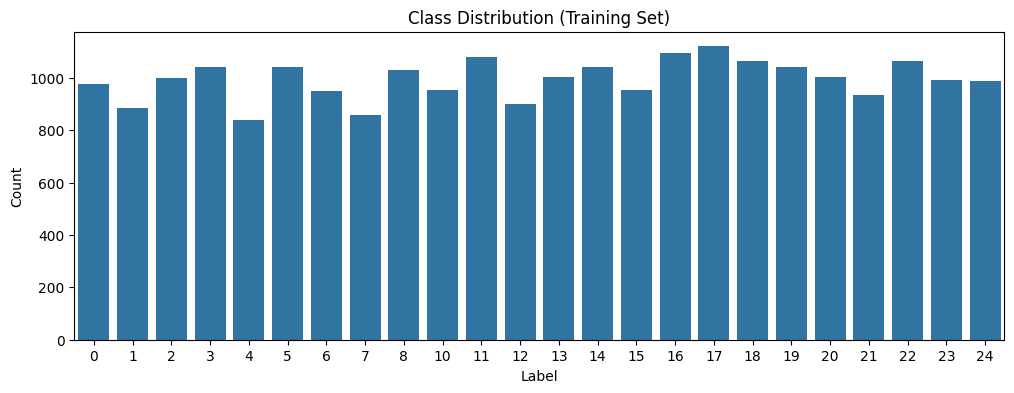

In [ ]:
plt.figure(figsize=(12, 4))
sns.countplot(x=df_train["label"])
plt.title("Class Distribution (Training Set)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


In [ ]:
class_counts = df_train["label"].value_counts().sort_index()
print(class_counts)


label
0      978
1      885
2      999
3     1040
4      838
5     1040
6      950
7      857
8     1029
10     955
11    1078
12     899
13    1004
14    1043
15     952
16    1095
17    1120
18    1064
19    1041
20    1005
21     933
22    1065
23     993
24     988
Name: count, dtype: int64


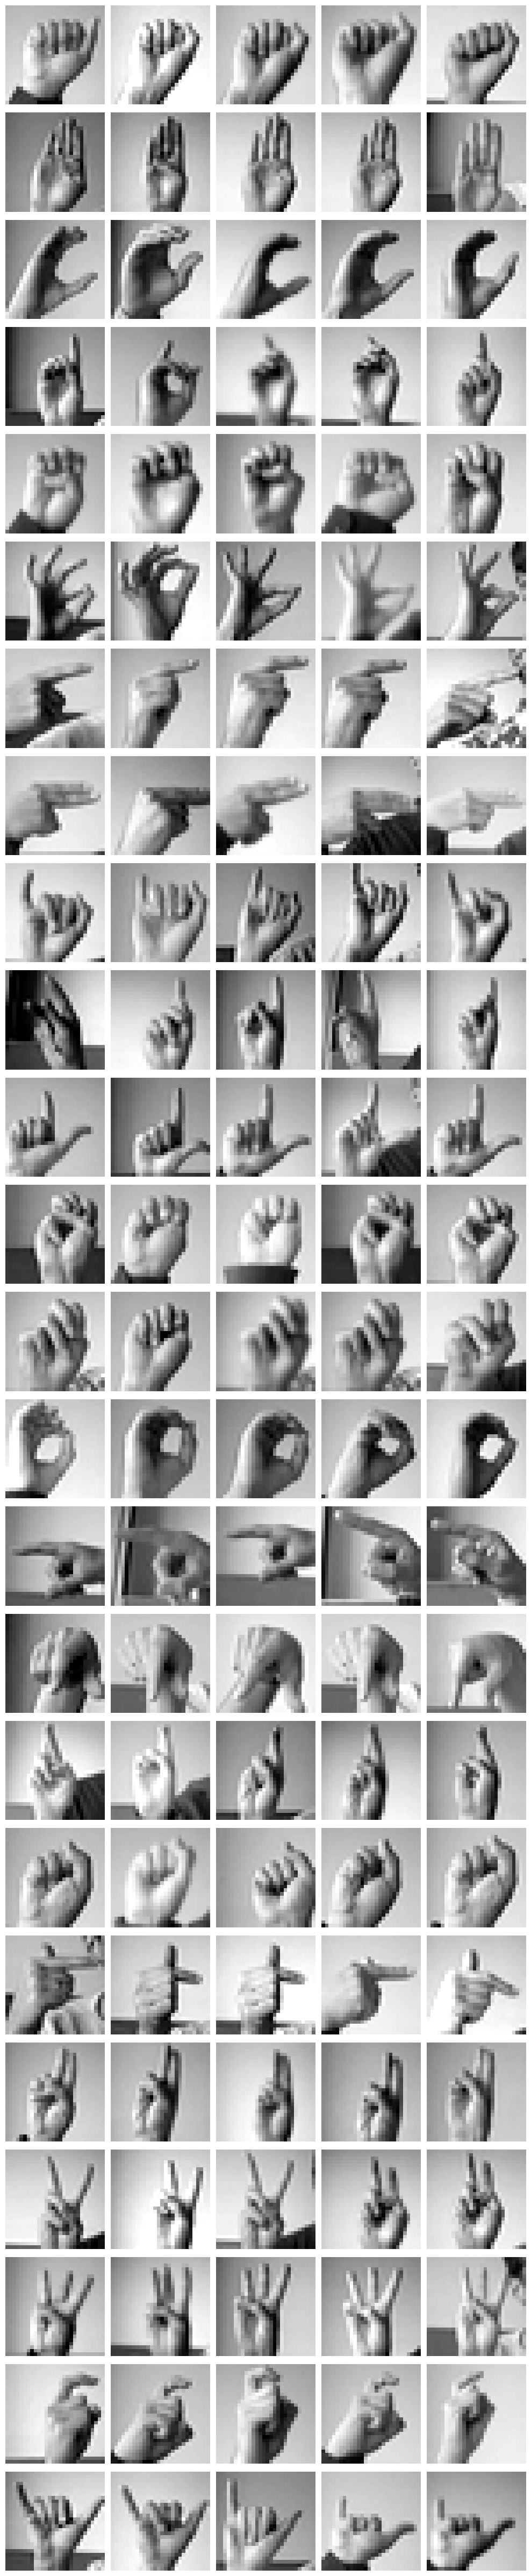

In [ ]:
PIXEL_COLS = [col for col in df_train.columns if col.startswith("pixel")]
IMG_SIZE = 28


def plot_samples_per_class(df, n_samples=5):
    labels = sorted(df["label"].unique())
    fig, axes = plt.subplots(len(labels), n_samples, figsize=(n_samples * 2, len(labels) * 2))

    for row, label in enumerate(labels):
        samples = df[df["label"] == label].sample(n_samples, random_state=42)
        for col, (_, sample) in enumerate(samples.iterrows()):
            img = sample[PIXEL_COLS].values.reshape(IMG_SIZE, IMG_SIZE)
            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_ylabel(f"Label {label}", fontsize=10)

    plt.tight_layout()
    plt.show()
plot_samples_per_class(df_train, n_samples=5)

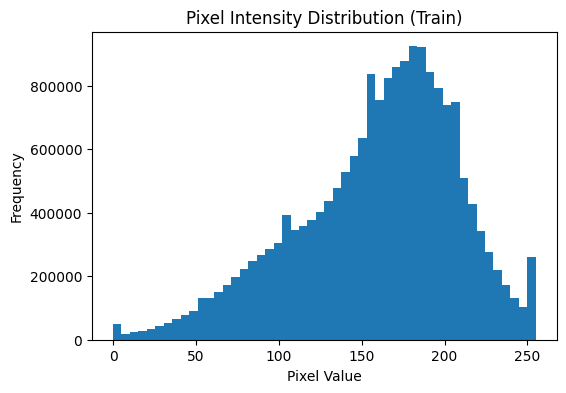

In [ ]:
pixels = df_train[PIXEL_COLS].values.flatten()

plt.figure(figsize=(6, 4))
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution (Train)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


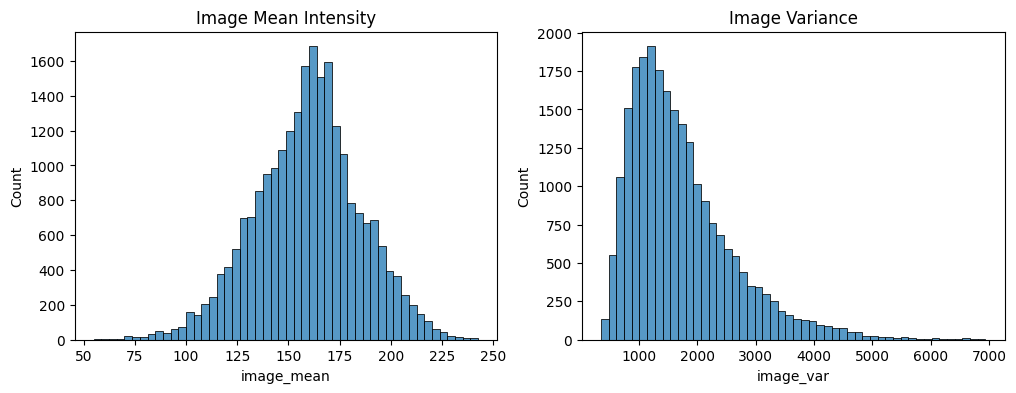

In [ ]:
df_train["image_mean"] = df_train[PIXEL_COLS].mean(axis=1)
df_train["image_var"] = df_train[PIXEL_COLS].var(axis=1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_train["image_mean"], bins=50)
plt.title("Image Mean Intensity")

plt.subplot(1, 2, 2)
sns.histplot(df_train["image_var"], bins=50)
plt.title("Image Variance")

plt.show()


In [ ]:
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio (max / min): {imbalance_ratio:.2f}")


Imbalance ratio (max / min): 1.34


Class imbalance is less than 1.5, so it is good

In [ ]:
low_var_threshold = df_train["image_var"].quantile(0.01)
high_var_threshold = df_train["image_var"].quantile(0.99)

outliers = df_train[
    (df_train["image_var"] < low_var_threshold) |
    (df_train["image_var"] > high_var_threshold)
]

print(f"Detected {len(outliers)} potential outliers")


Detected 478 potential outliers


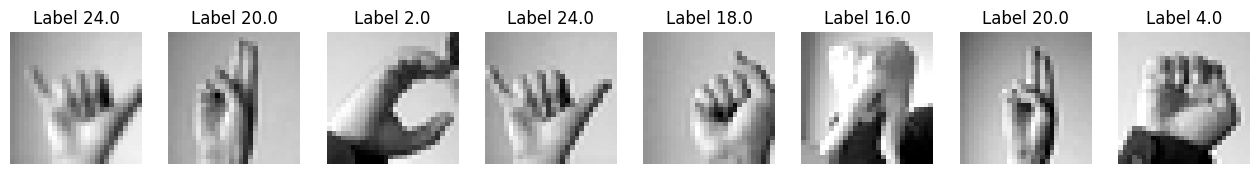

In [ ]:
def visualize_outliers(df, n=10):
    samples = df.sample(min(n, len(df)), random_state=42)
    fig, axes = plt.subplots(1, len(samples), figsize=(len(samples) * 2, 2))

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = row[PIXEL_COLS].values.reshape(IMG_SIZE, IMG_SIZE)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Label {row['label']}")
        ax.axis("off")

    plt.show()
visualize_outliers(outliers, n=8)


In [ ]:
print("Train pixel count:", len(PIXEL_COLS))
print("Test pixel count:", len([c for c in df_test.columns if c.startswith("pixel")]))


Train pixel count: 784
Test pixel count: 784


In [ ]:
train_min, train_max = df_train[PIXEL_COLS].min().min(), df_train[PIXEL_COLS].max().max()
test_min, test_max = df_test.filter(like="pixel").min().min(), df_test.filter(like="pixel").max().max()

print(f"Train range: [{train_min}, {train_max}]")
print(f"Test range:  [{test_min}, {test_max}]")


Train range: [0.0, 255.0]
Test range:  [0, 255]


In [ ]:
print("Train missing values:", df_train.isna().sum().sum())
print("Test missing values:", df_test.isna().sum().sum())

Train missing values: 462
Test missing values: 0


In [ ]:
df_train["label"].isna().sum()

np.int64(0)

In [ ]:
missing_per_col = df_train.isna().sum().sort_values(ascending=False)
missing_per_col.head(10)

,0
pixel784,1
pixel768,1
pixel767,1
pixel766,1
pixel765,1
pixel764,1
pixel763,1
pixel762,1
pixel761,1
pixel760,1


In [ ]:
df_train[PIXEL_COLS] = df_train[PIXEL_COLS].fillna(0)
df_test[PIXEL_COLS] = df_test[PIXEL_COLS].fillna(0)

In [ ]:
# Check for blank images in test set
test_means = df_test.filter(like="pixel").mean(axis=1)
blank_images = (test_means == 0).sum()

print(f"Blank images in test set: {blank_images}")


Blank images in test set: 0


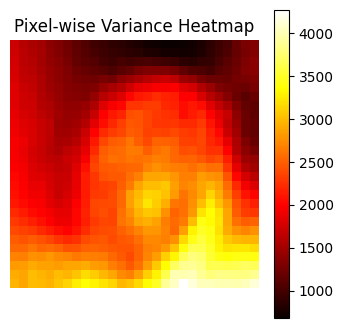

In [ ]:
pixel_variance = df_train[PIXEL_COLS].var().values.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(pixel_variance, cmap="hot")
plt.colorbar()
plt.title("Pixel-wise Variance Heatmap")
plt.axis("off")
plt.show()


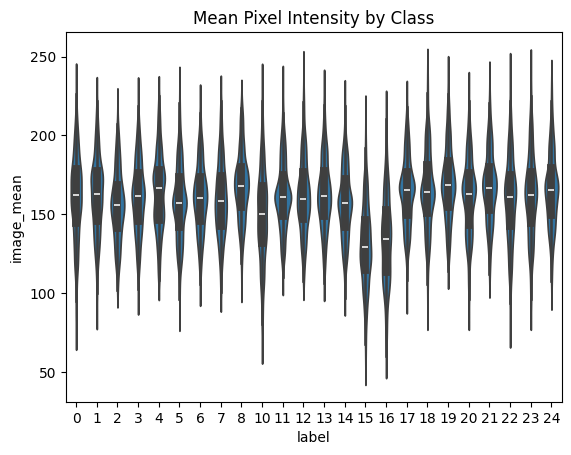

In [ ]:
sns.violinplot(x="label", y="image_mean", data=df_train)
plt.title("Mean Pixel Intensity by Class")
plt.show()


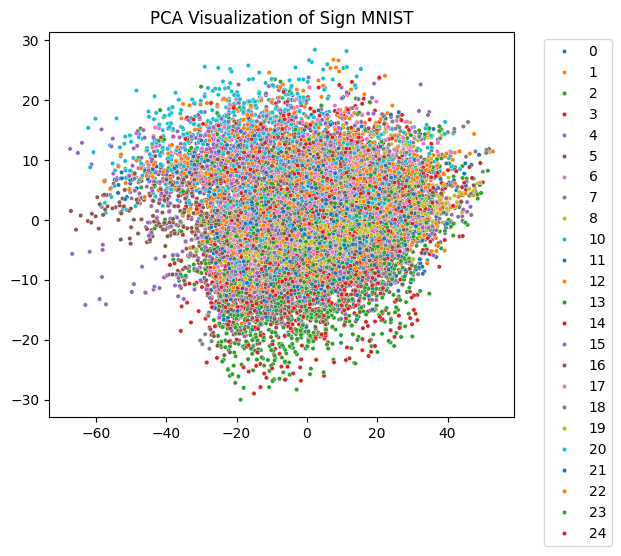

In [ ]:
X = df_train[PIXEL_COLS].values
y = df_train["label"].values

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="tab10", s=10)
plt.title("PCA Visualization of Sign MNIST")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()


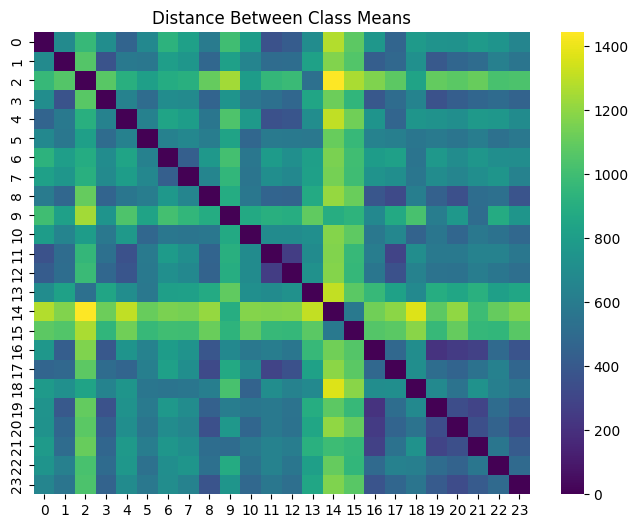

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

class_means = df_train.groupby("label")[PIXEL_COLS].mean()

dist_matrix = euclidean_distances(class_means)

plt.figure(figsize=(8,6))
sns.heatmap(dist_matrix, cmap="viridis")
plt.title("Distance Between Class Means")
plt.show()


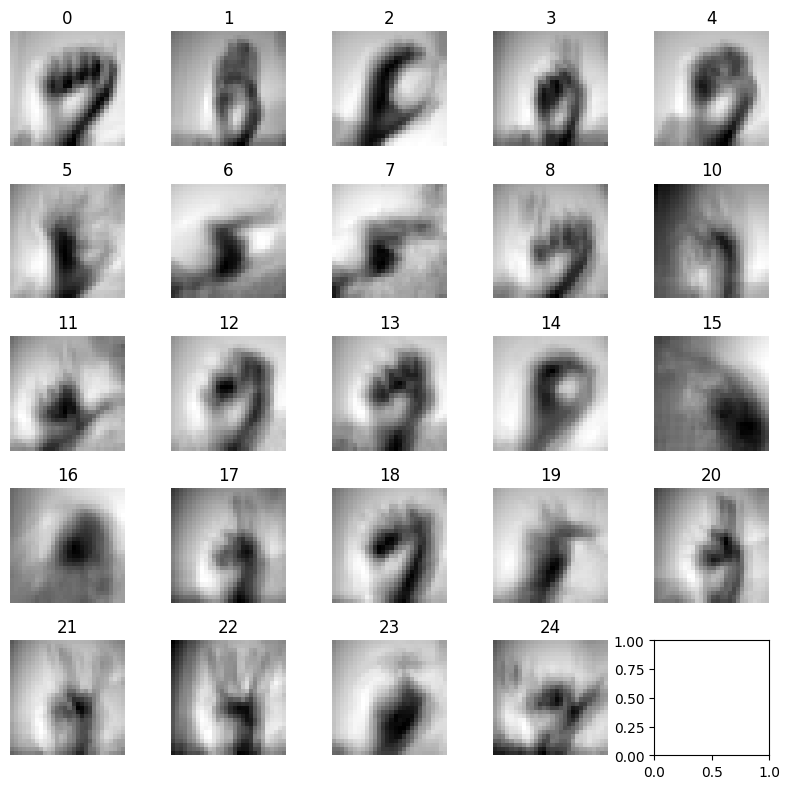

In [ ]:
labels = sorted(df_train["label"].unique())

fig, axes = plt.subplots(5,5, figsize=(8,8))

for i, label in enumerate(labels):
    mean_img = df_train[df_train["label"]==label][PIXEL_COLS].mean().values.reshape(28,28)

    ax = axes[i//5, i%5]
    ax.imshow(mean_img, cmap="gray")
    ax.set_title(f"{label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


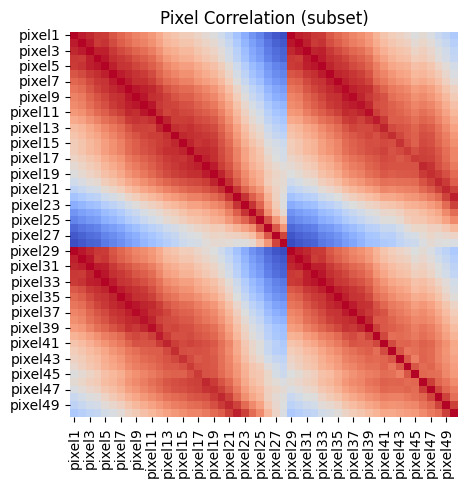

In [ ]:
sample_pixels = df_train[PIXEL_COLS].iloc[:1000]
corr = sample_pixels.corr()

plt.figure(figsize=(5,5))
sns.heatmap(corr.iloc[:50,:50], cmap="coolwarm", cbar=False)
plt.title("Pixel Correlation (subset)")
plt.show()
